Q1. Data Loading & Understanding

 a) Load the dataset into Python.

 b) Display the first 5 rows.

 c) Check the shape of the dataset.

 d) Display the data types of each column.



In [66]:
import pandas as pd
df = pd.read_csv('loan_approval - loan_approval.csv')

In [14]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [7]:
df.shape
df.dtypes

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,bool


Q2. Data Cleaning

a) Check for missing values in the dataset.

b) Handle missing values appropriately.

c) Identify categorical columns present in the dataset.

In [8]:
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


There is no missing values


In [9]:
categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['name', 'city'], dtype='object')


Q3. Exploratory Data Analysis (EDA)

a) Plot the distribution of the target variable.

b) Analyze the relationship between one numerical feature and the target variable.

c) Analyze the relationship between Years of Employment and the target variable.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

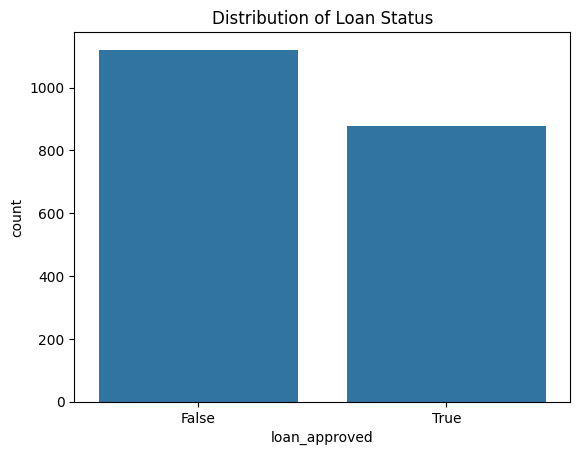

In [16]:
sns.countplot(x='loan_approved', data=df)

plt.title("Distribution of Loan Status")
plt.show()

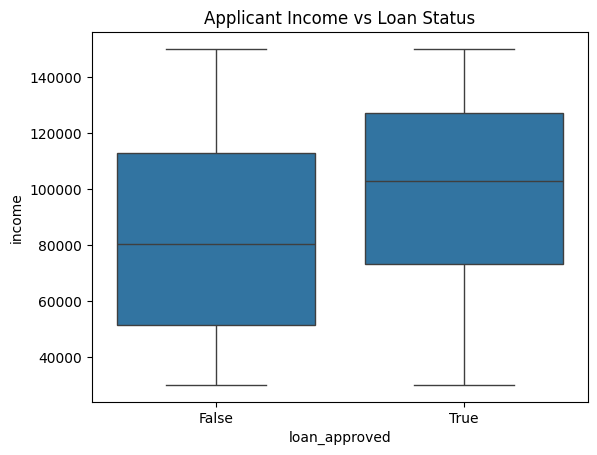

In [17]:
sns.boxplot(x='loan_approved', y='income', data=df)

plt.title("Applicant Income vs Loan Status")
plt.show()

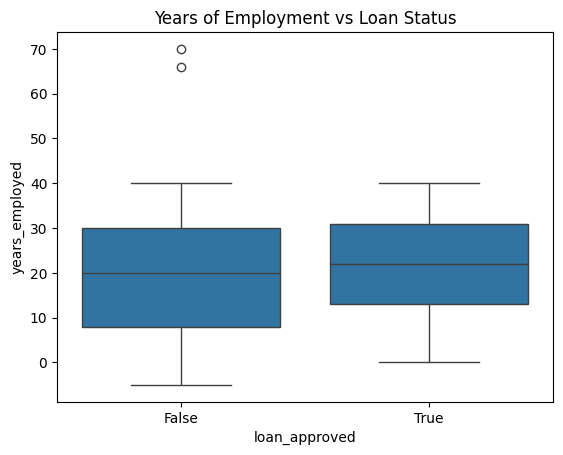

In [18]:
sns.boxplot(x='loan_approved', y='years_employed', data=df)

plt.title("Years of Employment vs Loan Status")
plt.show()

Q4. Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method.

 b) Treat outliers using capping techniques

In [19]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [20]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

income: 0 outliers
credit_score: 3 outliers
loan_amount: 0 outliers
years_employed: 2 outliers
points: 0 outliers


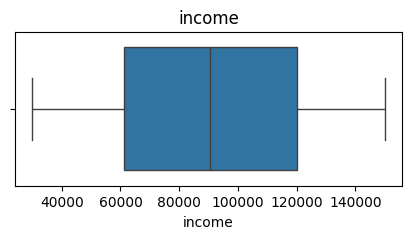

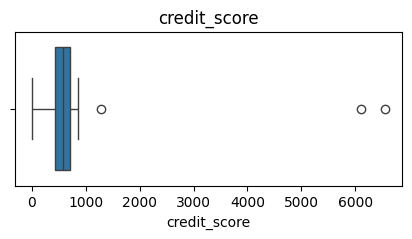

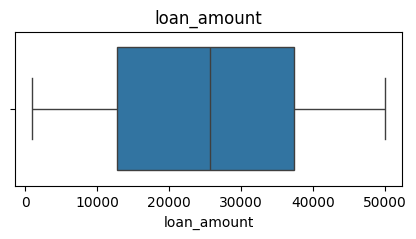

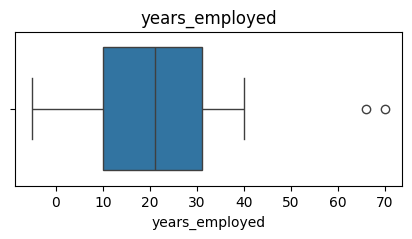

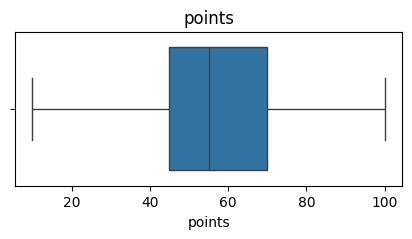

In [21]:
for col in num_cols:

    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])

    plt.title(col)
    plt.show()

In [22]:
# Treat outliers using capping techniques
#Capping using IQR boundaries
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)

In [23]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   float64
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   float64
 6   points          2000 non-null   int64  
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 111.5+ KB


,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,574.546250,25308.503000,20.476500,56.680000
std,34487.874907,162.442674,14207.320147,11.852993,18.638033
min,30053.000000,11.000000,1022.000000,-5.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,716.000000,37380.500000,31.000000,70.000000
max,149964.000000,1140.500000,49999.000000,62.500000,100.000000


Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.

In [77]:
df['loan_approved'] = df['loan_approved'].astype(int)
print(df['loan_approved'].head())

0    0
1    0
2    0
3    0
4    0
Name: loan_approved, dtype: int64


In [78]:
df.drop(['city'], axis=1, inplace=True)

Q6. Feature Selection and Data Splitting

a) Separate independent variables (X) and dependent variable (y).

b) Split the dataset into training and testing sets.

In [81]:
X = df.drop('loan_approved', axis=1)

In [74]:
y = df['loan_approved']

In [82]:
#Convert categorical columns into numerical format
X = pd.get_dummies(X, drop_first=True)

In [83]:
#b) Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


Q7. Apply feature scaling to the dataset using StandardScaler.


In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaler = StandardScaler()

In [48]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Q8. Logistic Regression Model Building

a) Train a Logistic Regression model.

b) Predict the output for test data.

In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
model = LogisticRegression()

In [84]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [86]:
#Predict output for test data
y_pred = model.predict(X_test_scaled)
print(y_pred)

[0 1 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 0
 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1
 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 0
 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 0 1
 1 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 0 0 0 1 1
 1 0 1 1 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1
 0 0 0 1 0 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 0 1 1 1 0 1
 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 0 0 1 1]


Q9. Model Evaluation – Confusion Matrix

a) Generate the confusion matrix.

b) Interpret the results.

In [87]:
from sklearn.metrics import confusion_matrix

In [88]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[215   2]
 [ 26 157]]


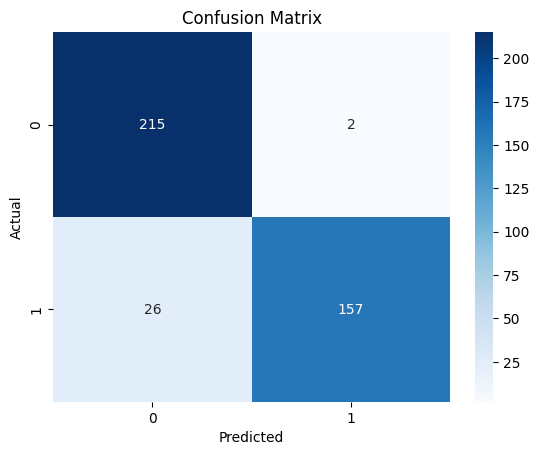

In [89]:
#Visualize confusion matrix
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [92]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.93


Q10. Model Evaluation – ROC Curve & AUC

a) Plot the ROC curve.

b) Calculate the AUC score.

In [93]:
from sklearn.metrics import roc_curve, roc_auc_score

In [94]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [95]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

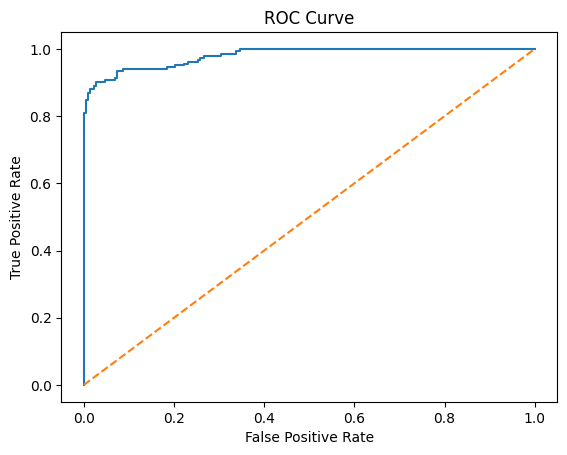

In [96]:
plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [97]:
#Calculate AUC Score

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.9801314497242578
